# The Correlation Between Survival Rates in Himalayan Mountain Expeditions and Climbers Economical Backgrounds
**Student Name:** Elif Çamlıkaya

**ID**: 35191

I will create a new Jupyter Notebook for my Himalayan climbers data that will contain the datasets of average 76000 climbers climbing record of the high Himalayan mountains and GDP dataset of each year from 1960 to 2019. Here are the links of my datasets:

This link contains the dataset that contains the members.csv file with all the demographic and survival data of the climbers:

https://www.kaggle.com/datasets/majunbajun/himalayan-climbing-expeditions

This is the official page where I collected the "GDP per capita (current US$)" dataset:

https://data.worldbank.org/indicator/NY.GDP.PCAP.CD



 Since the World Bank data stores years as columns, I will reshape it using the `melt` function so it matches my climbers dataset. Finally, I will merge them together based on the climber's citizenship and the exact year of their expedition to create my dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(context='talk', style='whitegrid', palette='colorblind')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(context='talk', style='whitegrid', palette='colorblind')

# 1. Loading  the Datasets
climbers_df = pd.read_csv('members.csv')
gdp_df = pd.read_csv('API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv', skiprows=4)

# 2. Cleaning and Reshaping the Data Set
cols_to_drop = ['Country Code', 'Indicator Name', 'Indicator Code', 'Unnamed: 68']
gdp_df = gdp_df.drop(columns=[col for col in cols_to_drop if col in gdp_df.columns])

gdp_long = pd.melt(gdp_df,
                   id_vars=['Country Name'],
                   var_name='year',
                   value_name='gdp_per_capita')

gdp_long['year'] = pd.to_numeric(gdp_long['year'], errors='coerce')
gdp_long = gdp_long.dropna(subset=['year'])
gdp_long['year'] = gdp_long['year'].astype(int)

# 3. Merging the Datasets
final_work = pd.merge(climbers_df, gdp_long,
                    left_on=['citizenship', 'year'],
                    right_on=['Country Name', 'year'],
                    how='left')

print("Data successfully merged! Total rows:", len(final_work))

Data successfully merged! Total rows: 76519


In this part I will make category of the economic data. I will divide the `gdp_per_capita` into three equal categories (Low, Middle, and High Income) using the `qcut` function. After creating this new column,I make the graph of distributions of gender, age, and a new income brackets to see how they relate to the death rate.

In [4]:
analysis_df = final_work.dropna(subset=['gdp_per_capita', 'age', 'sex']).copy()

analysis_df['Income_Bracket'] = pd.qcut(analysis_df['gdp_per_capita'],
                                        q=3,
                                        labels=['Low Income', 'Middle Income', 'High Income'])

print(analysis_df[['citizenship', 'year', 'gdp_per_capita', 'Income_Bracket']].head())

  citizenship  year  gdp_per_capita Income_Bracket
0      France  1978      9166.59012  Middle Income
1      France  1978      9166.59012  Middle Income
2      France  1978      9166.59012  Middle Income
3      France  1978      9166.59012  Middle Income
4      France  1978      9166.59012  Middle Income


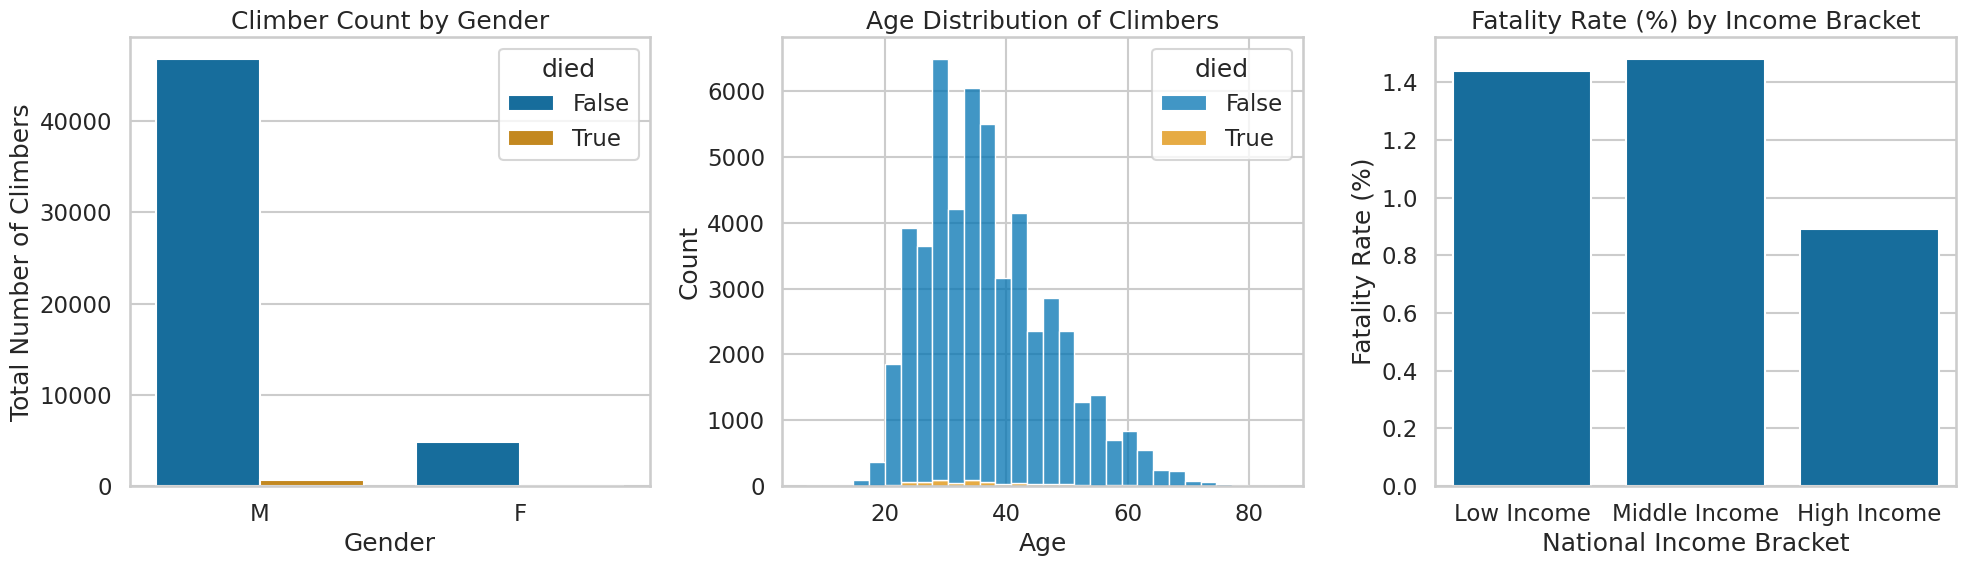

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.countplot(data=analysis_df, x='sex', hue='died', ax=axes[0])
axes[0].set_title('Climber Count by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Total Number of Climbers')

# Chart 1: Demographics (Age)
sns.histplot(data=analysis_df, x='age', hue='died', multiple="stack", bins=30, ax=axes[1])
axes[1].set_title('Age Distribution of Climbers')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

# Chart 2: Economics (Fatality Rate by Income)
income_fatality_rate = analysis_df.groupby('Income_Bracket', observed=True)['died'].mean() * 100

sns.barplot(x=income_fatality_rate.index, y=income_fatality_rate.values, ax=axes[2])
axes[2].set_title('Fatality Rate (%) by Income Bracket')
axes[2].set_xlabel('National Income Bracket')
axes[2].set_ylabel('Fatality Rate (%)')

plt.tight_layout()
plt.show()

Now let's see how these features mathematically behave. I will test my hypotheses to see if the differences we observed in the charts are statistically significant or just random chance.

 **1-Does GDP per capita affects the survival rate of the climbers?**
* **Null Hypothesis 1)** GDP per capita doesn't affect the survival rate.
* **Alternative Hypothesis 1)** GDP per capita affects the survival rate.

**2-Does gender affects the survival rate of the climbers?**

* **Null Hypothesis 2)** Climber's gender doesn't affect the survival rate.
* **Alternative Hypothesis 2)** Climber's gender affects the survival rate.

In [5]:
#
# T-TEST (GDP vs Survival)
#
gdp_survived = analysis_df[analysis_df['died'] == False]['gdp_per_capita']
gdp_died = analysis_df[analysis_df['died'] == True]['gdp_per_capita']

t_stat, p_value_gdp = stats.ttest_ind(gdp_survived, gdp_died, equal_var=False)

print("---GDP vs SURVIVAL ---")
print(f"P_Value: {p_value_gdp:.5f}")
if p_value_gdp < 0.05:
    print("GDP affects survival.")
else:
    print("Not Significant. Any difference in GDP is probably a random chance.")

print("\n")

#
#CHI-SQUARE TEST (Gender vs Survival)
#
contingency_table = pd.crosstab(analysis_df['sex'], analysis_df['died'])
chi2, p_value_gender, dof, expected = stats.chi2_contingency(contingency_table)

print("--- GENDER vs SURVIVAL ---")
print(f"P_Value: {p_value_gender:.5f}")
if p_value_gender < 0.05:
    print("Gender is correlated with survival.")
else:
    print("Any difference between genders is probably a random chance.")

---GDP vs SURVIVAL ---
P_Value: 0.00000
GDP affects survival.


--- GENDER vs SURVIVAL ---
P_Value: 0.00011
Gender is correlated with survival.
